# 02 — Evaluation: ResNet-50 Baseline

Load the best saved checkpoint and evaluate on the held-out test set.

**Sections**
1. Load checkpoint
2. Test-set accuracy, precision, recall, F1 (macro & per-class)
3. Confusion matrix
4. Cross-dataset probe: run the PlantVillage model on Plant Pathology images

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from tqdm.auto import tqdm

ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data  import make_pv_loaders, make_pp_loaders
from src.model import build_model

DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CKPT_PATH = ROOT / "models" / "resnet50_pv_best.pt"
print(f"Device     : {DEVICE}")
print(f"Checkpoint : {CKPT_PATH}  (exists: {CKPT_PATH.exists()})")

Device     : cpu
Checkpoint : C:\Users\jake\Documents\2026\CPTS 434\Leaf-Health-Analyzer\models\resnet50_pv_best.pt  (exists: True)


## 1. Load checkpoint

In [2]:
IMG_SIZE   = 224   # must match what was used during training
BATCH_SIZE = 64
SEED       = 42

ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
classes = ckpt["classes"]

model = build_model(
    arch="resnet50",
    num_classes=len(classes),
    task="single",
    pretrained=False,   # weights will come from checkpoint
).to(DEVICE)
model.load_state_dict(ckpt["model_state"])
model.eval()

print(f"Loaded checkpoint from epoch {ckpt['epoch']}")
print(f"Checkpoint val loss: {ckpt['val_loss']:.4f}  val acc: {ckpt['val_acc']:.4f}")
print(f"Classes: {len(classes)}")

Loaded checkpoint from epoch 2
Checkpoint val loss: 0.0459  val acc: 0.9849
Classes: 38


## 2. Test-set metrics

In [3]:
_, _, test_loader, _ = make_pv_loaders(
    root=ROOT,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    num_workers=0,
    seed=SEED,
)
print(f"Test images: {len(test_loader.dataset):,}  ({len(test_loader)} batches)")

Test images: 8,146  (128 batches)


In [4]:
all_preds, all_labels = [], []

with torch.inference_mode():
    for imgs, labels in tqdm(test_loader, desc="Test inference"):
        imgs = imgs.to(DEVICE)
        preds = model(imgs).argmax(1).cpu()
        all_preds.append(preds)
        all_labels.append(labels)

all_preds  = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

accuracy = (all_preds == all_labels).mean()
print(f"\nTest accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

c:\Users\jake\Documents\2026\CPTS 434\Leaf-Health-Analyzer\venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Test inference:   0%|          | 0/128 [00:00<?, ?it/s]


Test accuracy: 0.9859 (98.59%)


In [5]:
report = classification_report(
    all_labels, all_preds,
    target_names=classes,
    digits=4,
)
print(report)

report_path = ROOT / "models" / "resnet50_pv_test_report.txt"
report_path.write_text(report)
print(f"Saved to {report_path.name}")

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     0.9789    0.9894    0.9841        94
                                 Apple___Black_rot     0.9894    1.0000    0.9947        93
                          Apple___Cedar_apple_rust     1.0000    1.0000    1.0000        41
                                   Apple___healthy     1.0000    0.9919    0.9959       246
                               Blueberry___healthy     0.9956    0.9956    0.9956       226
          Cherry_(including_sour)___Powdery_mildew     1.0000    1.0000    1.0000       158
                 Cherry_(including_sour)___healthy     1.0000    0.9922    0.9961       128
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.8810    0.9610    0.9193        77
                       Corn_(maize)___Common_rust_     0.9890    1.0000    0.9944       179
               Corn_(maize)___Northern_Leaf_Blight     0.9783    0.9184    0.94

## 3. Confusion matrix

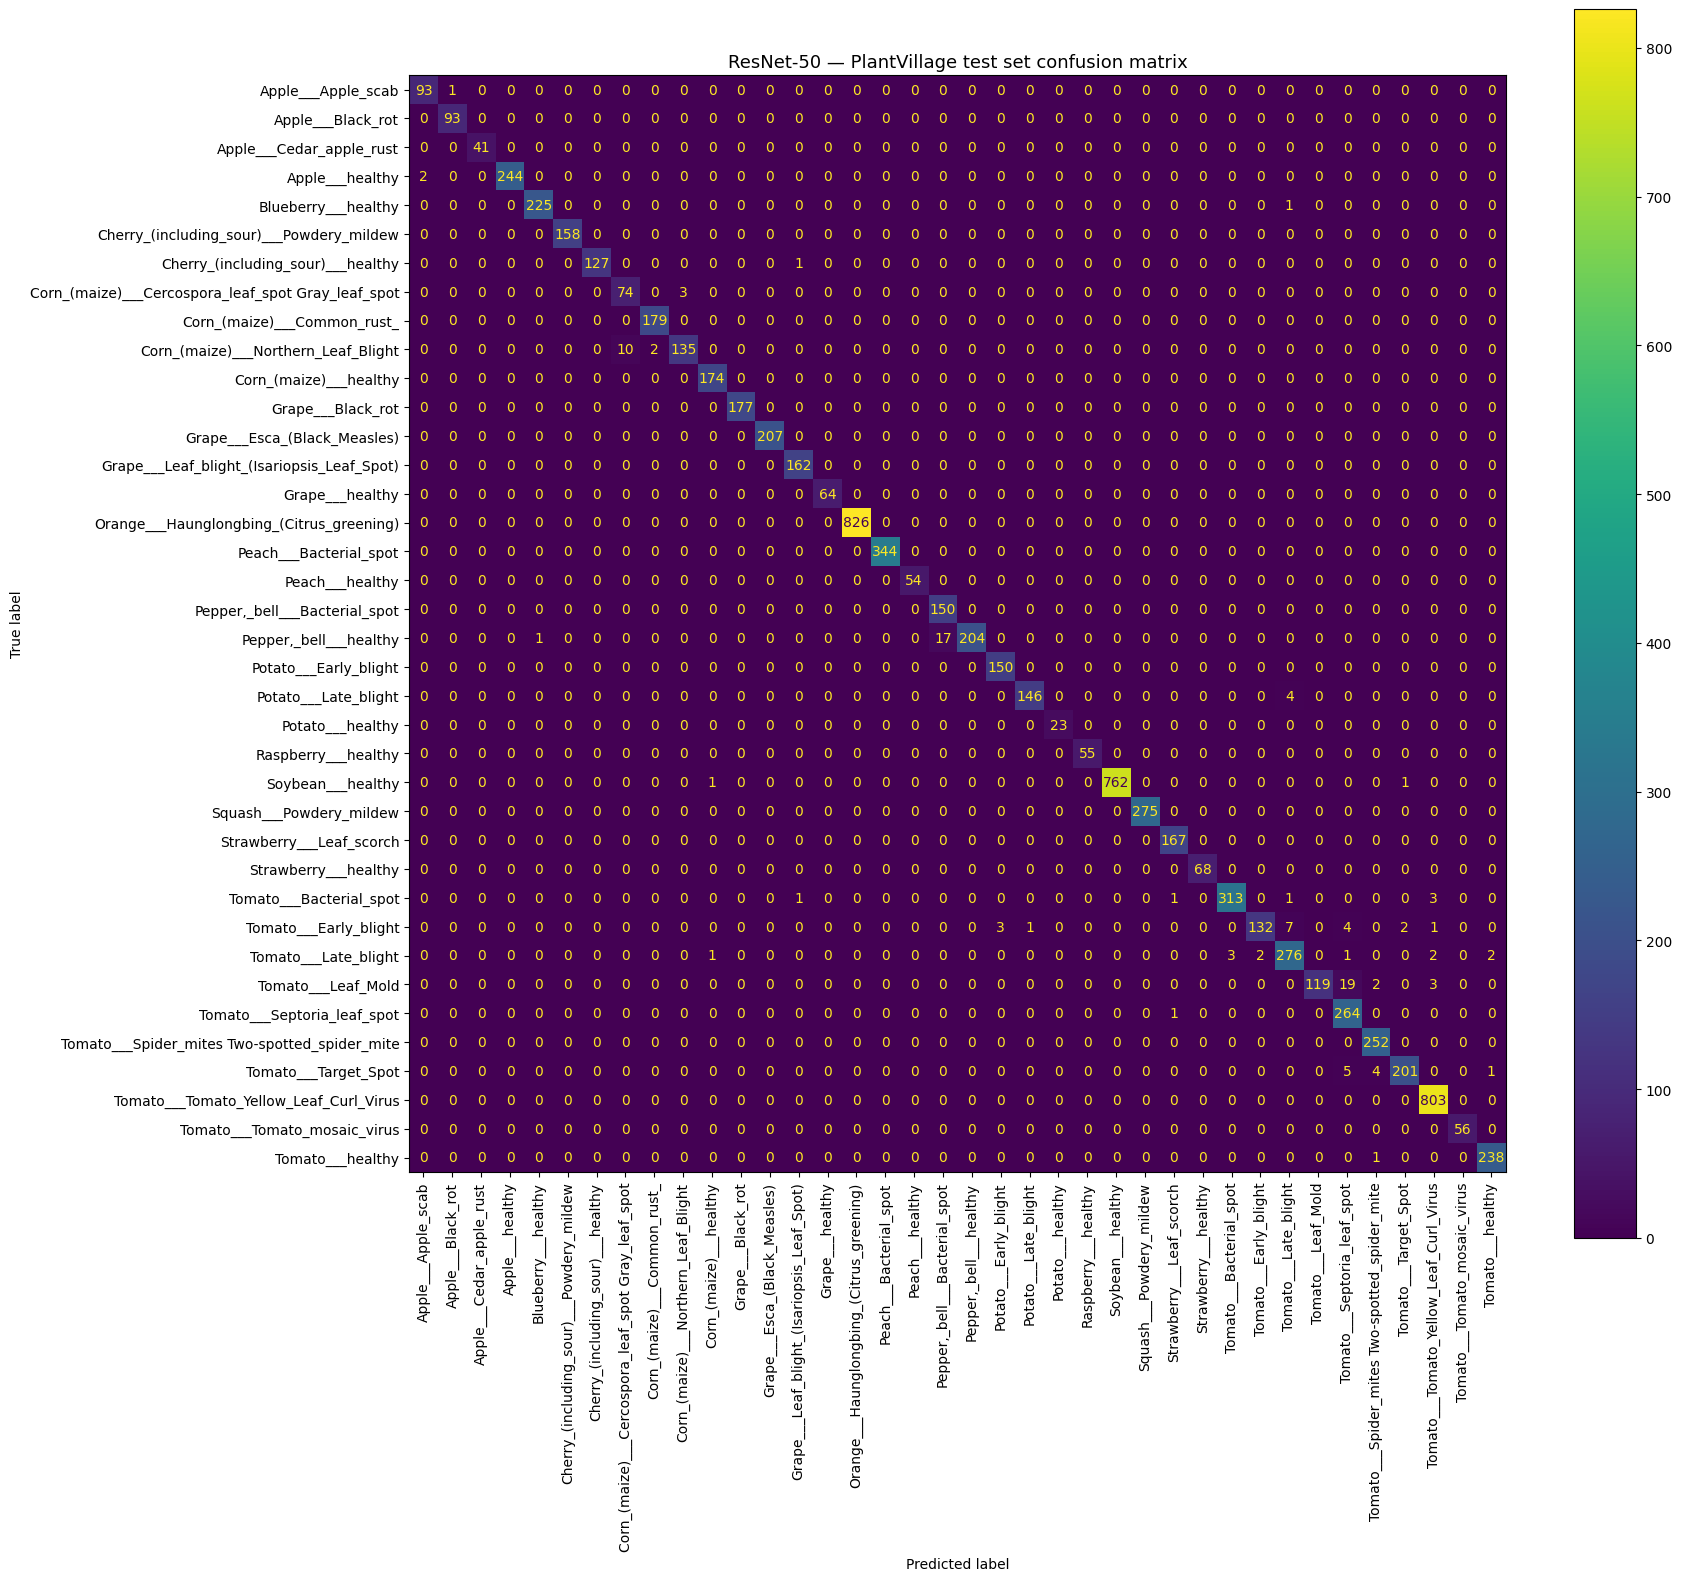


Top-5 most confused pairs (true -> predicted):
  Tomato___Leaf_Mold                       -> Tomato___Septoria_leaf_spot               (19 images)
  Pepper,_bell___healthy                   -> Pepper,_bell___Bacterial_spot             (17 images)
  Corn_(maize)___Northern_Leaf_Blight      -> Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot  (10 images)
  Tomato___Early_blight                    -> Tomato___Late_blight                      (7 images)
  Tomato___Target_Spot                     -> Tomato___Septoria_leaf_spot               (5 images)


In [6]:
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(18, 16))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(ax=ax, colorbar=True, xticks_rotation=90, values_format="d")
ax.set_title("ResNet-50 — PlantVillage test set confusion matrix", fontsize=13)
plt.tight_layout()
plt.savefig(ROOT / "models" / "resnet50_pv_confusion.png", dpi=150)
plt.show()

# Highlight the most-confused pairs
np.fill_diagonal(cm, 0)
pairs = [(cm[i, j], classes[i], classes[j])
         for i in range(len(classes)) for j in range(len(classes)) if i != j]
pairs.sort(reverse=True)
print("\nTop-5 most confused pairs (true -> predicted):")
for count, true_cls, pred_cls in pairs[:5]:
    print(f"  {true_cls:40s} -> {pred_cls:40s}  ({count} images)")

## 4. Cross-dataset probe

The PlantVillage model was trained on clean lab photos.  
Here we apply it to Plant Pathology 2021 field images to measure the domain gap.  
Because the label spaces differ, we look at **top-1 confidence** and **entropy** as proxies for model certainty rather than accuracy.

Plant Pathology test images: 2,795


c:\Users\jake\Documents\2026\CPTS 434\Leaf-Health-Analyzer\venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Cross-dataset inference:   0%|          | 0/44 [00:00<?, ?it/s]

In-domain inference:   0%|          | 0/128 [00:00<?, ?it/s]


                                Mean confidence   Mean entropy (bits)
PlantVillage (in-domain)                 0.9873                0.0551
Plant Pathology (cross)                  0.6533                1.5436


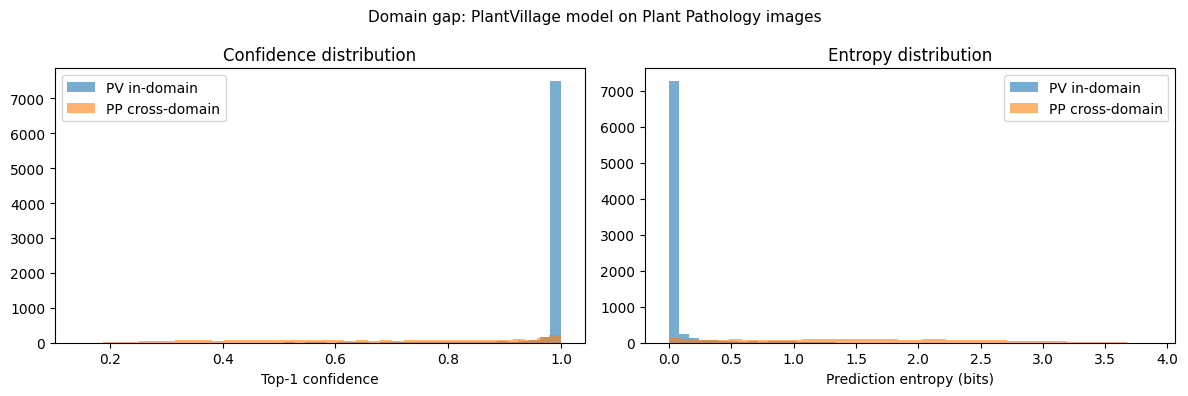

In [7]:
import torch.nn.functional as F

_, _, pp_test_loader, pp_classes = make_pp_loaders(
    root=ROOT,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    num_workers=0,
    seed=SEED,
)
print(f"Plant Pathology test images: {len(pp_test_loader.dataset):,}")

confidences, entropies = [], []

with torch.inference_mode():
    for imgs, _ in tqdm(pp_test_loader, desc="Cross-dataset inference"):
        imgs  = imgs.to(DEVICE)
        probs = F.softmax(model(imgs), dim=1).cpu()
        confidences.extend(probs.max(1).values.tolist())
        # Shannon entropy (bits): higher = less certain
        ent = -(probs * probs.clamp(min=1e-9).log2()).sum(1)
        entropies.extend(ent.tolist())

# PV in-domain baseline for comparison
pv_confidences, pv_entropies = [], []
with torch.inference_mode():
    for imgs, _ in tqdm(test_loader, desc="In-domain inference"):
        imgs  = imgs.to(DEVICE)
        probs = F.softmax(model(imgs), dim=1).cpu()
        pv_confidences.extend(probs.max(1).values.tolist())
        ent = -(probs * probs.clamp(min=1e-9).log2()).sum(1)
        pv_entropies.extend(ent.tolist())

print(f"\n{'':30s} {'Mean confidence':>16}  {'Mean entropy (bits)':>20}")
print(f"{'PlantVillage (in-domain)':30s} {np.mean(pv_confidences):>16.4f}  {np.mean(pv_entropies):>20.4f}")
print(f"{'Plant Pathology (cross)':30s} {np.mean(confidences):>16.4f}  {np.mean(entropies):>20.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(pv_confidences, bins=40, alpha=0.6, label="PV in-domain")
axes[0].hist(confidences,    bins=40, alpha=0.6, label="PP cross-domain")
axes[0].set_xlabel("Top-1 confidence")
axes[0].set_title("Confidence distribution")
axes[0].legend()

axes[1].hist(pv_entropies, bins=40, alpha=0.6, label="PV in-domain")
axes[1].hist(entropies,    bins=40, alpha=0.6, label="PP cross-domain")
axes[1].set_xlabel("Prediction entropy (bits)")
axes[1].set_title("Entropy distribution")
axes[1].legend()

plt.suptitle("Domain gap: PlantVillage model on Plant Pathology images", fontsize=11)
plt.tight_layout()
plt.savefig(ROOT / "models" / "cross_domain_confidence.png", dpi=150)
plt.show()